In [1]:
import sys
import pystac_client
import planetary_computer
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from datetime import timedelta

import datacube
import odc.stac
import odc.geo.xr
from odc.geo.geom import BoundingBox

sys.path.insert(1, "../../Tools/")
from dea_tools.datahandling import load_ard
from dea_tools.plotting import display_map, rgb



## Bushfire mapping with SAR (cband from Sentinel 1)

I ran the methods from Hosseini and Lim 2023 over kangeroo island 2019 - 2020 fire and found the best results came from using what they describe as Radar Burn Difference (VH), other papers describe it as deltaVH, it is simply subtracting the VH backscatter values for the pre-fire image from the post-fire image.

The literature states that this methodology does not work in every ecosystem and can be effected by terrain. The method works with some sucess over Kangeroo Island but less well when tested in other locations that burnt in the 2019-2020 summer. 

In [2]:
def calculate_date_range(fire_date):
    # Calculate the start and end date for baseline data load based of fire date
    start_date_pre = datetime.strftime(
        ((datetime.strptime(fire_date, '%Y-%m-%d')) - timedelta(days=30)), '%Y-%m-%d')
    end_date_pre = datetime.strftime(
        ((datetime.strptime(fire_date, '%Y-%m-%d')) - timedelta(days=1)),
        '%Y-%m-%d')
    
    # Calculate end date for post fire data load
    start_date_post = datetime.strftime(
        ((datetime.strptime(fire_date, '%Y-%m-%d')) + timedelta(days=1)),
        '%Y-%m-%d')
    end_date_post = datetime.strftime(
        ((datetime.strptime(fire_date, '%Y-%m-%d')) + timedelta(days=30)),
        '%Y-%m-%d')


    return (start_date_pre,end_date_pre),(start_date_post,end_date_post)


def calculate_coords(shape):
    #get max extent coordinates out of burnt area shapefile (ensure in epsg 4326) for data loading
    shape= shape.to_crs(4326)
                # Get bounding box coordinates and add a buffer
    lon_min, lat_min, lon_max, lat_max = shape.total_bounds
    buffer = 0.04
    x = (lon_min - buffer, lon_max + buffer)
    y = (lat_min - buffer, lat_max + buffer)
    return x,y


In [3]:
dc = datacube.Datacube(app="Planetary_computer")

## define parameters for query


In [4]:
import geopandas as gpd

#open burn boundary for KI

fire_boundary_file =  gpd.read_file("/home/jovyan/gdata1/projects/Hazards/burn mapping/kangaroo_Island_SA_2020_CY_ARDC_polygons.gpkg")

#set burn date
fire_date = '2020-01-01'

#calulate time ranges for data load
first_range, second_range = calculate_date_range(fire_date)


#get bounds coors from shape
x,y = calculate_coords(fire_boundary_file)


In [5]:
# Display area on map

display_map(x=x, y=y)

In [6]:
# Open a client pointing to the Microsoft Planetary Computer data catalogue
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

In [7]:
# Convert data-cube style queries into something readable by `pystac_client`
bbox = BoundingBox.from_xy(x, y)
# time_range = "/".join(time)

# Search for STAC items from "sentinel-1-rtc" product
search = catalog.search(
    collections="sentinel-1-rtc",
    bbox=bbox,
    datetime=first_range,
)

# Check how many items were returned
items = search.item_collection()

# Load sentinel 1 with odc-stac
s1_dataset_pre = odc.stac.load(
    items,
    bbox=bbox,
    bands=["vv","vh"],
    crs="EPSG:3577",
    resolution=40,)

# Load sentinel 2



In [8]:
# Convert data-cube style queries into something readable by `pystac_client`
bbox = BoundingBox.from_xy(x, y)
# time_range = "/".join(time)

# Search for STAC items from "sentinel-1-rtc" product
search = catalog.search(
    collections="sentinel-1-rtc",
    bbox=bbox,
    datetime=second_range,
)

# Check how many items were returned
items = search.item_collection()

# Load sentinel 1 with odc-stac
s1_dataset_post = odc.stac.load(
    items,
    bbox=bbox,
    bands=["vv","vh"],
    crs="EPSG:3577",
    resolution=40,)


In [9]:
#convert backscatter to log scale for visulaisation

s1_dataset_pre = 10 * np.log10(s1_dataset_pre)
s1_dataset_post = 10 * np.log10(s1_dataset_post)

/env/lib/python3.10/site-packages/xarray/core/computation.py:831: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


In [10]:
# calculate vv/vh 'band' for rgb visualisation

s1_dataset_pre['vv/vh'] = s1_dataset_pre['vv'] - s1_dataset_pre['vh']
s1_dataset_post['vv/vh'] = s1_dataset_post['vv'] - s1_dataset_post['vh']

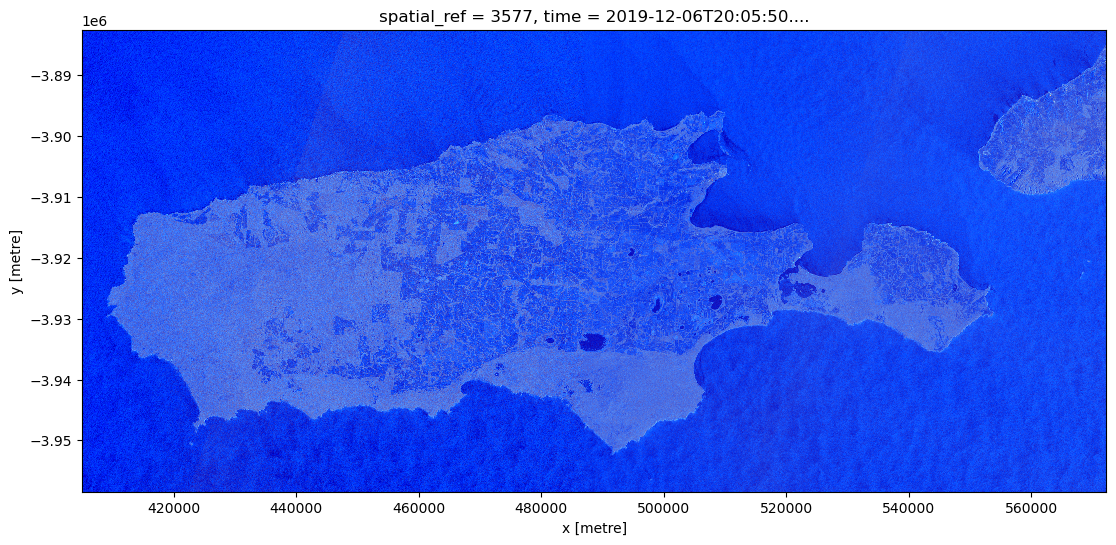

In [11]:
rgb(s1_dataset_pre, bands=['vh','vv','vv/vh'], index=0, percentile_stretch=(0.05,0.95))

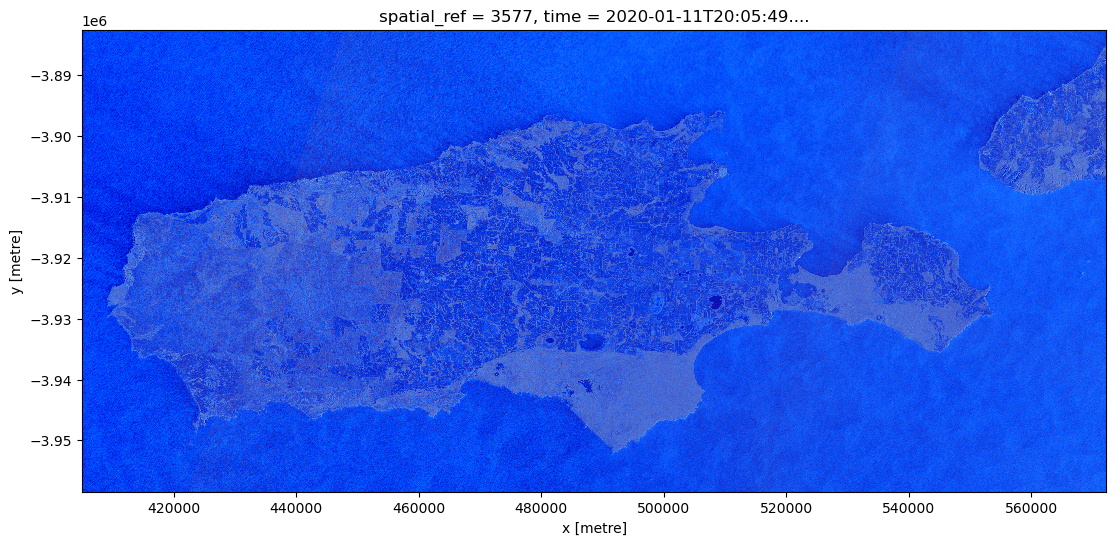

In [12]:
rgb(s1_dataset_post, bands=['vh','vv','vv/vh'], index=1, percentile_stretch=(0.05,0.95))

In [13]:
#set which image we are using (want an overpass that covers entire AOI
pree_fireimage = s1_dataset_pre.isel(time=0)
post_fireimage = s1_dataset_post.isel(time=1)

In [14]:
RBR =  pree_fireimage - post_fireimage
#calulate 

<Axes: title={'center': 'spatial_ref = 3577'}, xlabel='x [metre]', ylabel='y [metre]'>

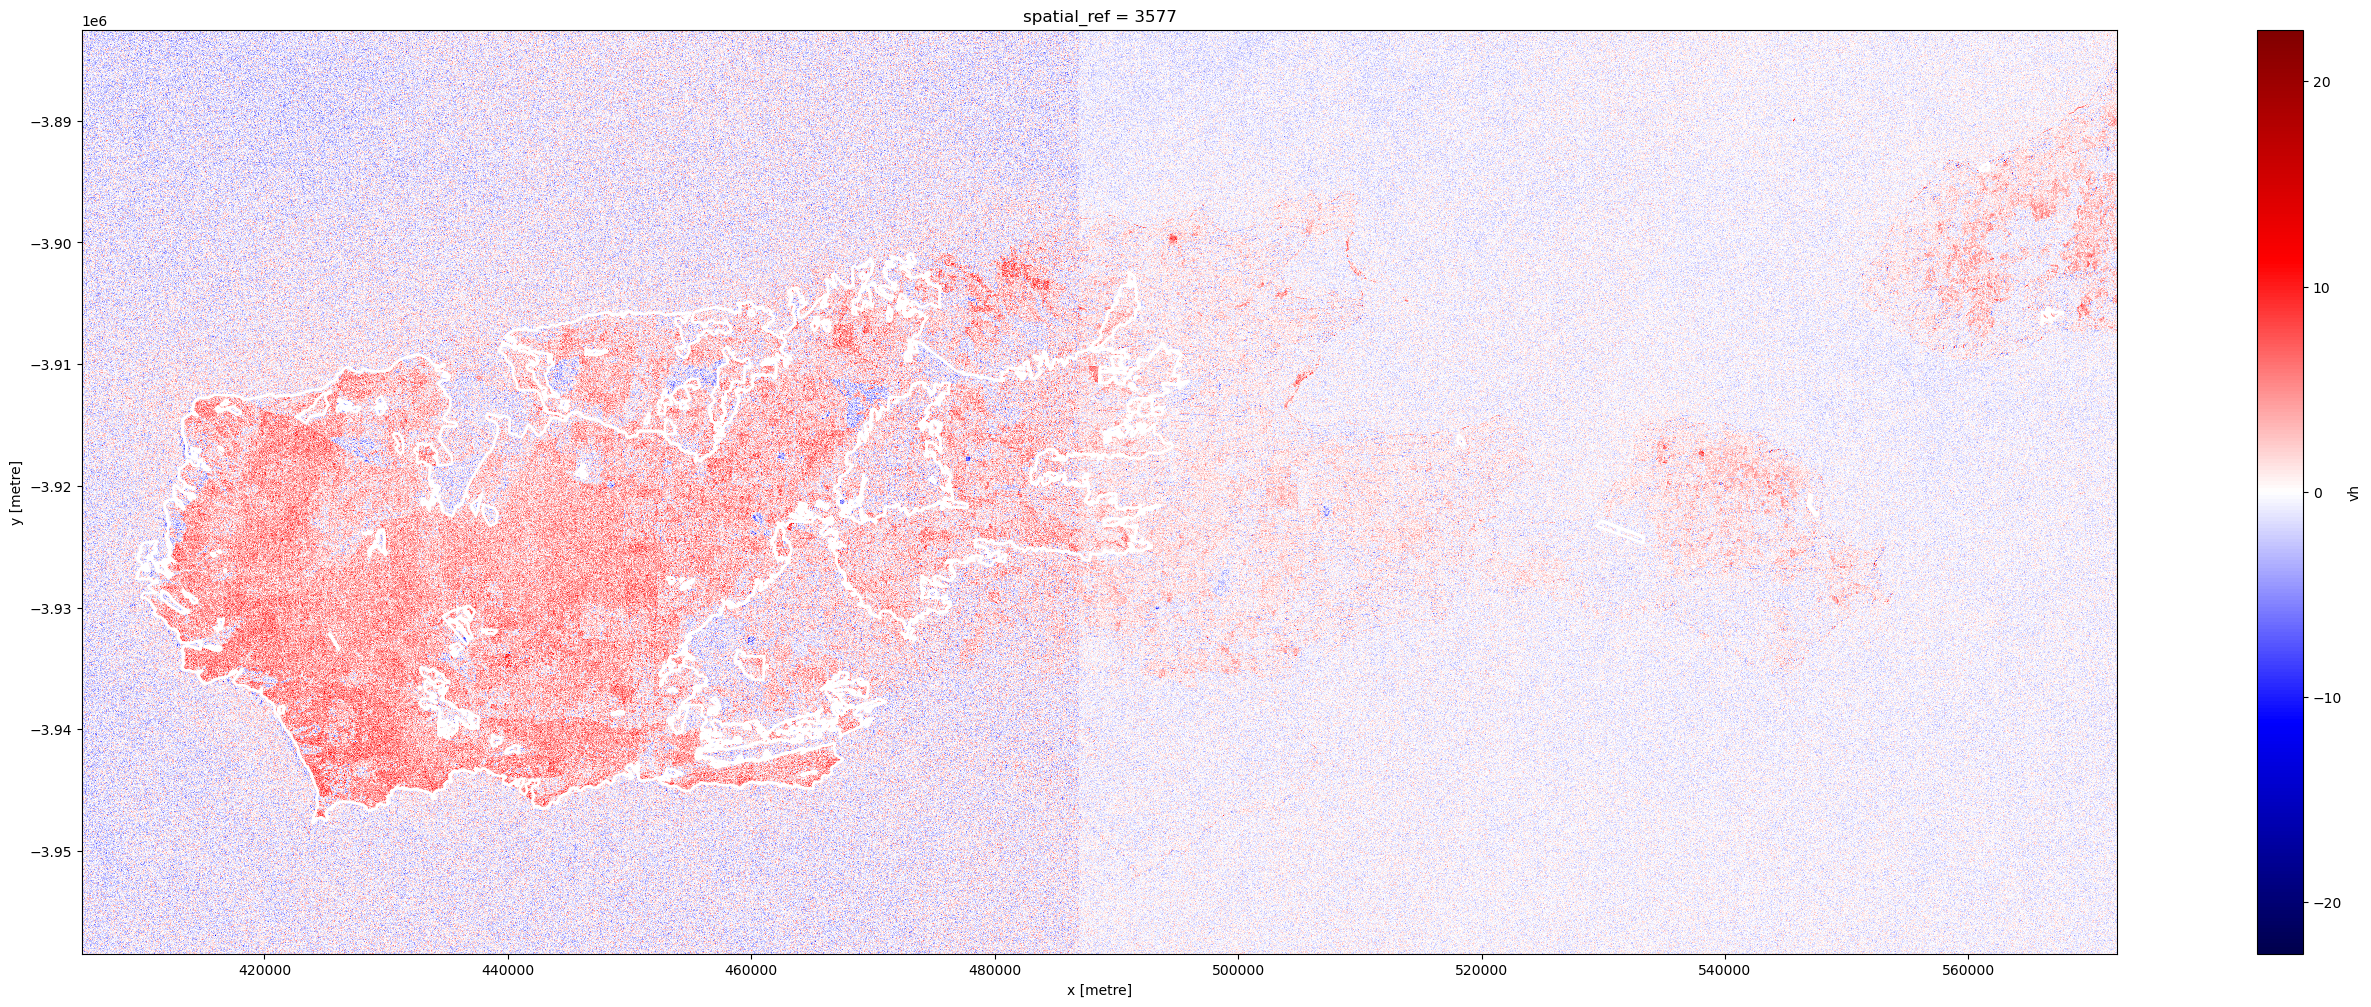

In [15]:
RBR['vh'].plot(cmap= 'seismic', size=12, aspect=3)
fire_boundary_file.boundary.plot(ax=plt.gca(), linewidth=2.0, color='w')